[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_1/01D-DataVisualization.ipynb)

# 01D — Data Visualization and Correlation
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 1, Notebook D — Hour 3 (continued)**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`01C` got the data into Python and summarised it. This notebook asks what it *looks* like.

That is not a decorative question. Summary statistics are a compression, and the last section of
this notebook shows four datasets with identical means, standard deviations and correlations that
look nothing alike. Everything here is about seeing what the numbers alone will not tell you.

## Learning objectives

By the end of this notebook, students should be able to:

- create histograms, scatter plots and box plots, and read them critically;
- read a box plot in terms of the numbers it is built from;
- compare distributions across groups, and see structure that overall summaries hide;
- interpret a correlation, and recognise what it cannot tell you;
- judge from exploratory plots whether a modelling problem is likely to be solvable;
- recognise the common ways a data analysis misleads its own author.

It continues directly from `01C`, and assumes the pandas covered there.

## Setup

Colab starts each notebook with a fresh runtime, so the imports and the dataset from `01C` have to
be loaded again here. This is the same loading code, with the same fallback.

The setup cell below loads the iris measurements. It first tries the copy on the web and, if that
fails, falls back to the copy bundled with `scikit-learn`, so a network problem cannot stop the
class. The `try` / `except` form it uses is Python's way of saying *attempt this; if it goes wrong,
do that instead* — **you are not expected to write it yet.** It is infrastructure, not material.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

try:
    iris = pd.read_csv(url)
except Exception:
    from sklearn.datasets import load_iris

    bunch = load_iris(as_frame=True)
    iris = bunch.frame.rename(columns={
        "sepal length (cm)": "sepal_length",
        "sepal width (cm)": "sepal_width",
        "petal length (cm)": "petal_length",
        "petal width (cm)": "petal_width"
    })
    iris["species"] = iris["target"].map(dict(enumerate(bunch.target_names)))
    iris = iris.drop(columns="target")

# 01C defined this while selecting columns; the plots below use it repeatedly.
numeric_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 1. Visualization: distributions

Tables are useful, but they can hide structure.

A visualization can often reveal patterns that are hard to see from numerical summaries alone.

The first kind of plot we consider is the **histogram**.

A histogram shows how often values fall into different intervals.

It helps answer questions such as:

- What range of values occurs?
- Where are most observations concentrated?
- Are there unusually small or large values?
- Is the distribution symmetric or skewed?
- Are there multiple groups hidden inside the data?

## 1.1 A first histogram

Let us start with the distribution of `sepal_length`.

The command

```python
iris["sepal_length"]
```

selects one numerical column.

The method

```python
.hist(...)
```

creates a histogram of that column.

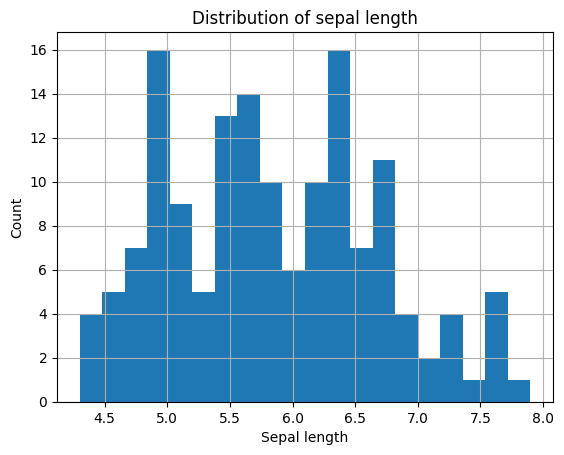

In [ ]:
iris["sepal_length"].hist(bins=20)

plt.xlabel("Sepal length")
plt.ylabel("Count")
plt.title("Distribution of sepal length")
plt.show()

The horizontal axis shows sepal length.

The vertical axis shows how many observations fall into each interval.

This plot gives more information than the mean alone.

For example, we can see:

- the approximate range of sepal lengths;
- where values are most concentrated;
- whether there are gaps or unusual values.

## 1.2 The number of bins matters

A histogram groups values into intervals called **bins**.

The number of bins affects the appearance of the plot.

Too few bins may hide structure.

Too many bins may make the plot look noisy.

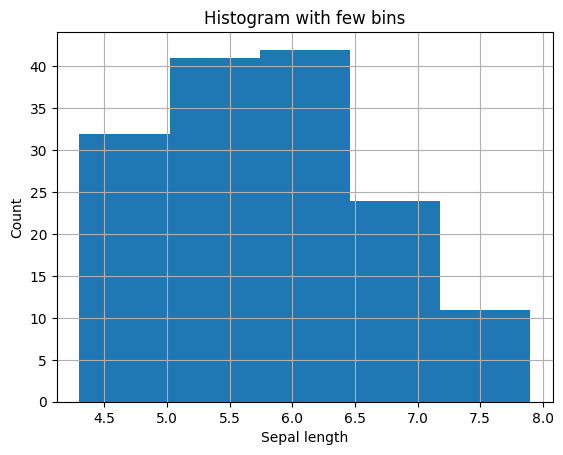

In [ ]:
iris["sepal_length"].hist(bins=5)

plt.xlabel("Sepal length")
plt.ylabel("Count")
plt.title("Histogram with few bins")
plt.show()

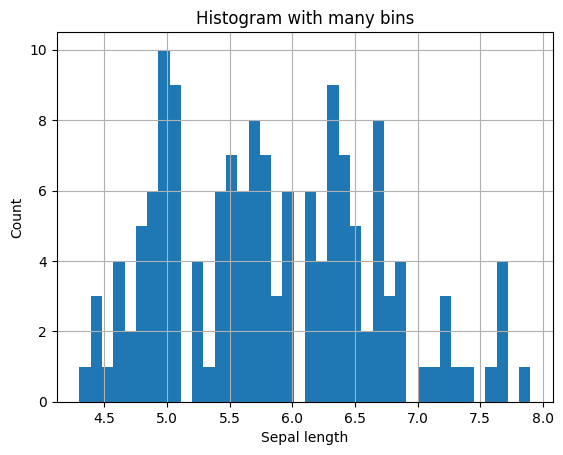

In [ ]:
iris["sepal_length"].hist(bins=40)

plt.xlabel("Sepal length")
plt.ylabel("Count")
plt.title("Histogram with many bins")
plt.show()

There is no universally correct number of bins.

A good practical habit is to try a few reasonable values and check whether the qualitative conclusion changes.

If the conclusion changes dramatically when the bin number changes, we should be cautious.

## 1.3 Comparing several variables

We can make histograms for several numerical variables.

This helps compare ranges and variability.

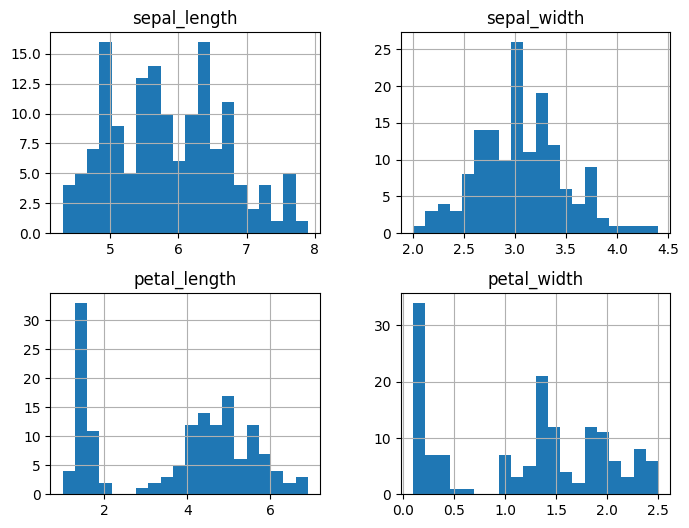

In [ ]:
iris[numeric_columns].hist(bins=20, figsize=(8, 6))

plt.show()

This compact view already suggests something important:

- sepal measurements and petal measurements have different distributions;
- petal length and petal width show stronger separation into groups;
- some variables may be more useful than others for distinguishing species.

This is exactly the kind of observation exploratory analysis is meant to produce.

## 1.4 Comparing distributions by group

The previous histograms ignored the species labels.

Sometimes we want to compare the distribution of one measurement across groups.

Here we compare petal length across species.

We can loop over the groups produced by `groupby`.

At each iteration:

- `species` is the group name;
- `group` is the part of the DataFrame corresponding to that species.

Here we use this to draw one histogram per species.

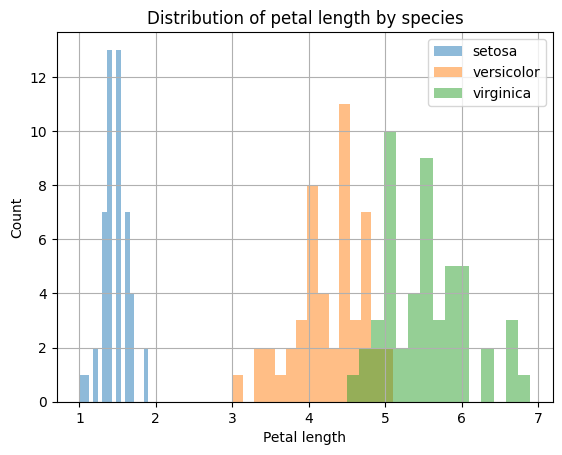

In [ ]:
for species, group in iris.groupby("species"):
    group["petal_length"].hist(alpha=0.5, bins=15, label=species)

plt.xlabel("Petal length")
plt.ylabel("Count")
plt.title("Distribution of petal length by species")
plt.legend()
plt.show()

This plot is much more informative than the global histogram.

It shows that:

- `setosa` has much smaller petal length than the other species;
- `versicolor` and `virginica` are closer to each other;
- petal length may be a strong feature for classification.

However, overlapping histograms can become hard to read when there are many groups or many variables.

Exploratory visualization is partly about choosing a plot that makes the relevant structure visible.

## 1.5 Histograms and scientific reasoning

A histogram is not just a decorative plot.

It can reveal:

- measurement ranges;
- outliers;
- multiple populations;
- skewed distributions;
- possible data-entry errors;
- differences between groups.

Before fitting a model, we should often look at the distributions of the main variables.

This is especially important in scientific data, where unexpected values may indicate either an error or an interesting phenomenon.

<div class="alert alert-success">
<b>Mini-exercise 1 — Histograms</b><br>
Using the Iris dataset:
<br><br>
1. Make a histogram of <code>petal_width</code>.<br>
2. Try at least two different values for <code>bins</code>.<br>
3. Make histograms of <code>petal_width</code> separately for each species.<br>
4. Based on the plots, does <code>petal_width</code> look useful for distinguishing species?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 2. Visualization: relationships

Histograms describe **one variable at a time**.

Much of science, however, is about **relationships between variables**.

The standard tool for looking at two numerical variables together is the **scatter plot**.

A scatter plot draws one point per observation, using one variable for the horizontal position and one for the vertical position.

It helps answer questions such as:

- Do larger values of one variable correspond to larger values of another?
- Is the relationship approximately linear, or clearly curved?
- Are there visible clusters?
- Are there outliers that do not follow the general pattern?
- How much scatter is there around the general trend?

## 2.1 A first scatter plot

The function

```python
plt.scatter(x, y)
```

takes two sequences of the same length and draws one point for each pair.

Here we plot sepal width against sepal length.

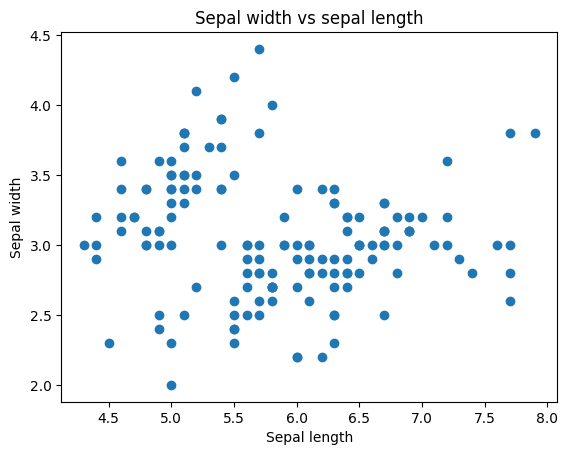

In [ ]:
plt.scatter(iris["sepal_length"], iris["sepal_width"])

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length")
plt.show()

Each point is one flower.

Its horizontal position is that flower's sepal length, and its vertical position is its sepal width.

Notice how little this plot resembles a clean trend. The points form a broad cloud.

If we had only computed the average sepal length and average sepal width, we would have learned almost nothing about this structure.

## 2.2 Overplotting: when points overlap

Scatter plots become harder to read when many points fall close together.

This is called **overplotting**: several points are drawn on top of one another, and we can no longer tell whether a region contains two observations or twenty.

Two simple remedies are:

- reduce the marker size with `s`;
- make markers partially transparent with `alpha`.

With `alpha=0.5`, a region where two points overlap appears darker than a region with a single point.

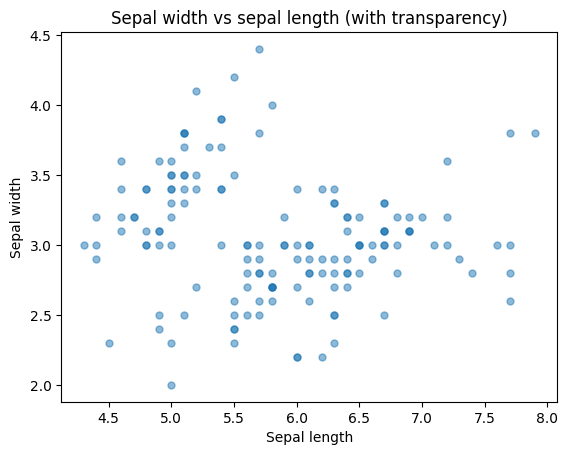

In [ ]:
plt.scatter(iris["sepal_length"], iris["sepal_width"], s=25, alpha=0.5)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length (with transparency)")
plt.show()

The darker regions now indicate where observations are concentrated.

This is a small change, but it matters. In large scientific datasets, overplotting can completely hide the density structure of the data.

A useful habit: whenever a scatter plot looks like a solid block of colour, suspect overplotting.

## 2.3 Adding a third variable

A scatter plot uses two spatial dimensions, but we can encode additional variables using **colour** or **marker size**.

Here we colour each point according to its petal length.

The argument `c` sets the colour of each point, and `plt.colorbar()` adds a scale so the colours can be interpreted.

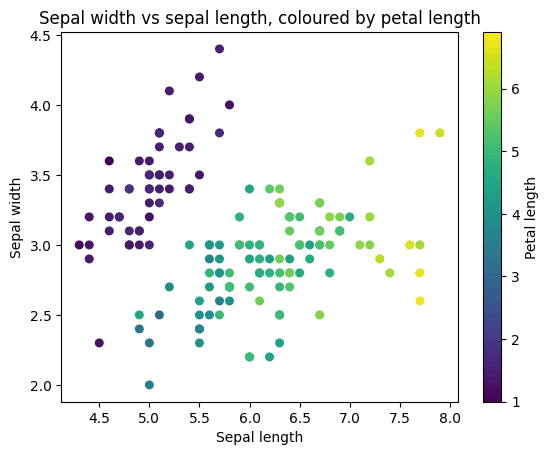

In [ ]:
scatter = plt.scatter(
    iris["sepal_length"],
    iris["sepal_width"],
    c=iris["petal_length"],
    s=30,
    cmap="viridis"
)

plt.colorbar(scatter, label="Petal length")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length, coloured by petal length")
plt.show()

This plot carries three variables at once.

A structure appears that was invisible before: the flowers with small petal length occupy the upper-left region, and they seem to form a separate group.

This is a good illustration of a general principle:

> Structure that is invisible in one projection of the data may become obvious in another.

Encoding works, but it has limits. Colour is much harder to read quantitatively than position, and adding a fourth or fifth encoded variable usually produces an unreadable plot.

## 2.4 The scatter matrix: all pairs at once

With four numerical variables there are six possible pairs.

Rather than making six plots by hand, pandas can produce a **scatter matrix**: a grid showing every variable against every other.

The diagonal shows the distribution of each individual variable.

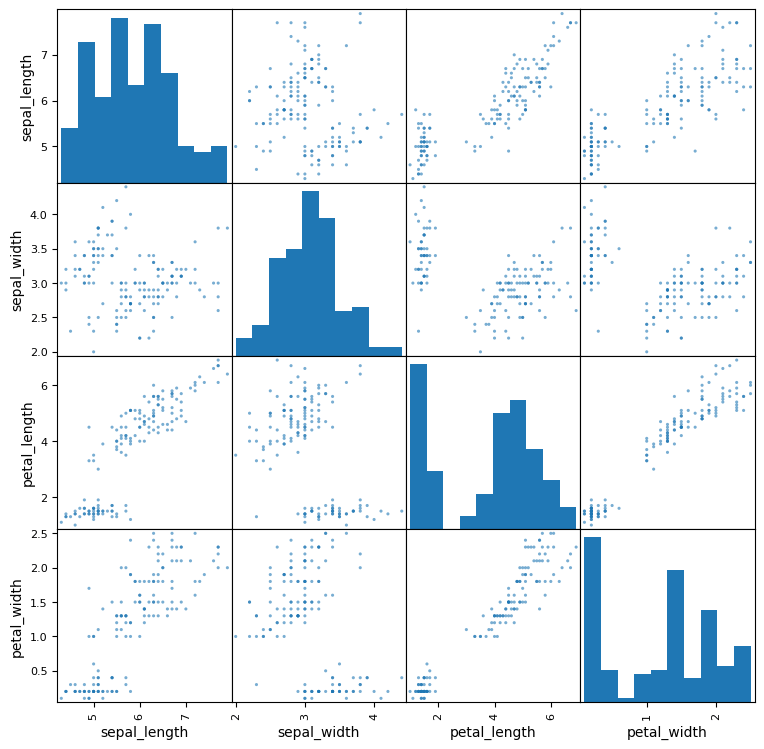

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    iris[numeric_columns],
    figsize=(9, 9),
    diagonal="hist",
    alpha=0.6,
    s=20
)

plt.show()

This single figure is a compact summary of the whole dataset.

Reading it row by row, we can already see that:

- `petal_length` and `petal_width` are strongly related to each other;
- both petal variables show a clear gap, suggesting two separate groups;
- `sepal_width` shows much less structure than the other variables;
- `sepal_length` is related to the petal measurements.

A scatter matrix is often the single most informative first plot for a small tabular dataset.

## 2.5 How scatter plots can mislead

A scatter plot is an interpretation, not a neutral record of the data.

The same points can suggest different conclusions depending on the axis ranges.

The two plots below show **exactly the same data**, with different vertical limits.

The call `plt.subplots(1, 2)` creates one figure containing a grid of plots — here one row of two.
It returns the figure and an array of axes, one per panel, and each panel is then drawn on
separately with `ax.scatter(...)` rather than `plt.scatter(...)`.

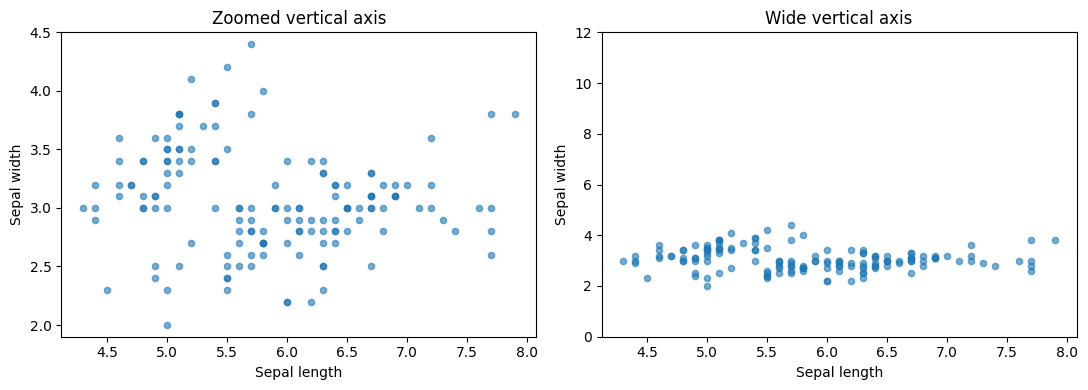

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, ylim, title in zip(
    axes,
    [(1.9, 4.5), (0.0, 12.0)],
    ["Zoomed vertical axis", "Wide vertical axis"]
):
    ax.scatter(iris["sepal_length"], iris["sepal_width"], s=20, alpha=0.6)
    ax.set_ylim(ylim)
    ax.set_xlabel("Sepal length")
    ax.set_ylabel("Sepal width")
    ax.set_title(title)

plt.tight_layout()
plt.show()

On the left the data look spread out and variable.

On the right they look tightly clustered and almost constant.

Neither plot is wrong, but they invite different conclusions.

When reading a plot, whether your own or someone else's, always check the axis ranges before forming an impression.

<div class="alert alert-success">
<b>Mini-exercise 2 — Scatter plots</b><br>
Using the Iris dataset:
<br><br>
1. Make a scatter plot of <code>petal_length</code> against <code>petal_width</code>.<br>
2. Add transparency and reduce the marker size.<br>
3. Colour the points by <code>sepal_length</code> and add a colour bar.<br>
4. Compare this plot with the sepal scatter plot from Section 2.1. Which pair of variables shows more structure?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 3. Visualization: groups

Many scientific datasets contain a **categorical label** in addition to numerical measurements:

- a species;
- a material class;
- an experimental condition;
- a detector state;
- a diagnosis.

When such a label exists, one of the most useful things we can do is look at whether the numerical measurements differ between groups.

This is the exploratory step that comes immediately before classification.

## 3.1 Why group structure matters

In Section 2.3 we saw a hint of separate groups when colouring by petal length.

The Iris dataset actually tells us the answer directly, because it contains a `species` column.

If the groups occupy clearly different regions of the plot, then a classification model is likely to succeed.

If the groups overlap completely, then either the measurements do not contain the relevant information, or we need different features.

This is worth emphasising:

> Looking at group separation before modelling tells us whether the modelling problem is likely to be easy, hard, or impossible with the available measurements.

## 3.2 Colouring points by group

We can loop over the groups produced by `groupby`.

At each iteration:

- `species` is the group name;
- `group` is the part of the DataFrame corresponding to that species.

Calling `plt.scatter` once per group means each group receives its own colour and its own legend entry.

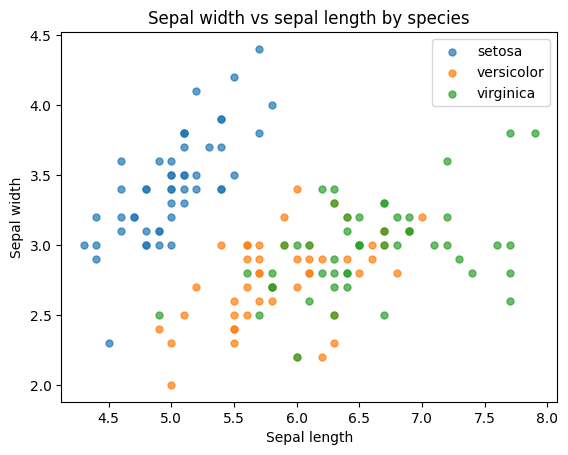

In [ ]:
for species, group in iris.groupby("species"):
    plt.scatter(group["sepal_length"], group["sepal_width"], label=species, s=25, alpha=0.7)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length by species")
plt.legend()
plt.show()

The shapeless cloud from Section 2.1 now has structure.

`setosa` occupies the upper-left region and is fairly well separated.

`versicolor` and `virginica` overlap substantially in these two variables.

So the sepal measurements alone would let us identify `setosa` reliably, but would struggle to distinguish the other two species.

## 3.3 Box plots by group

A scatter plot shows individual observations.

Sometimes we want a compact summary of **one variable across several groups**. A **box plot** does this.

The syntax

```python
iris.boxplot(column="petal_length", by="species")
```

means: summarise the column `petal_length`, split by the values of `species`.

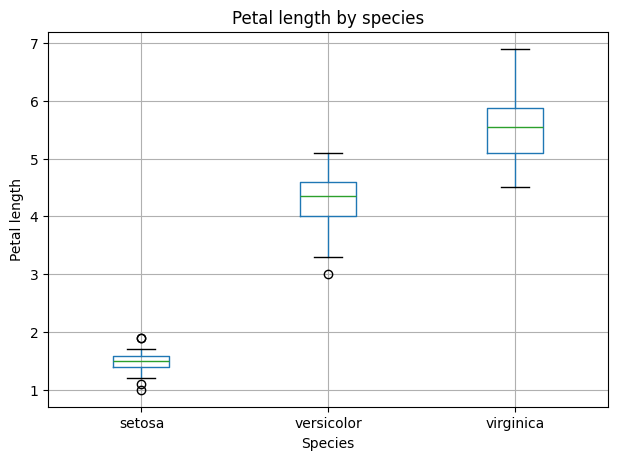

In [ ]:
iris.boxplot(column="petal_length", by="species", figsize=(7, 5))

plt.xlabel("Species")
plt.ylabel("Petal length")
plt.title("Petal length by species")
plt.suptitle("")
plt.show()

The extra call `plt.suptitle("")` simply removes the automatic title that pandas adds above the figure.

### Reading a box plot

Each box summarises the distribution of one group:

- the **line inside the box** is the median;
- the **box** spans the middle 50% of the data, from the 25th to the 75th percentile;
- the **whiskers** run out to the most distant observations that are not judged unusual;
- **individual points** beyond the whiskers are flagged as potential outliers.

Those descriptions are hard to picture from words alone. The figure below takes a single group —
the 50 versicolor flowers — and puts its box plot next to a histogram of the very same numbers,
turned on its side so that the two share a vertical axis.

Every feature of the box is drawn from the histogram beside it.

The cell below computes those numbers directly. `.quantile()` asks a column for the value below
which a given fraction of the data falls, so `.quantile([0.25, 0.50, 0.75])` returns the 25th,
50th and 75th percentiles at once. The first and third are conventionally called **Q1** and **Q3**,
and the distance between them is the **interquartile range**, written IQR — the width of the box,
and the unit in which the whiskers' reach is measured.

In [ ]:
versicolor = iris[iris["species"] == "versicolor"]["petal_length"]

# The five numbers a box plot is built from
q1, median, q3 = versicolor.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
lower_whisker = versicolor[versicolor >= lower_fence].min()
upper_whisker = versicolor[versicolor <= upper_fence].max()
outliers = versicolor[(versicolor < lower_fence) | (versicolor > upper_fence)]

print(f"1.5 x IQR      {1.5 * iqr:.2f}")
print(f"lower fence    {lower_fence:.2f}   (Q1 - 1.5 x IQR)")
print(f"upper fence    {upper_fence:.2f}   (Q3 + 1.5 x IQR)")
print()
print(f"lower whisker  {lower_whisker:.2f}")
print(f"Q1  (25%)      {q1:.2f}")
print(f"median (50%)   {median:.2f}")
print(f"Q3  (75%)      {q3:.2f}")
print(f"upper whisker  {upper_whisker:.2f}")
print(f"IQR = Q3 - Q1  {iqr:.2f}")
print(f"outliers       {sorted(outliers.tolist())}")

1.5 x IQR      0.90
lower fence    3.10   (Q1 - 1.5 x IQR)
upper fence    5.50   (Q3 + 1.5 x IQR)

lower whisker  3.30
Q1  (25%)      4.00
median (50%)   4.35
Q3  (75%)      4.60
upper whisker  5.10
IQR = Q3 - Q1  0.60
outliers       [3.0]


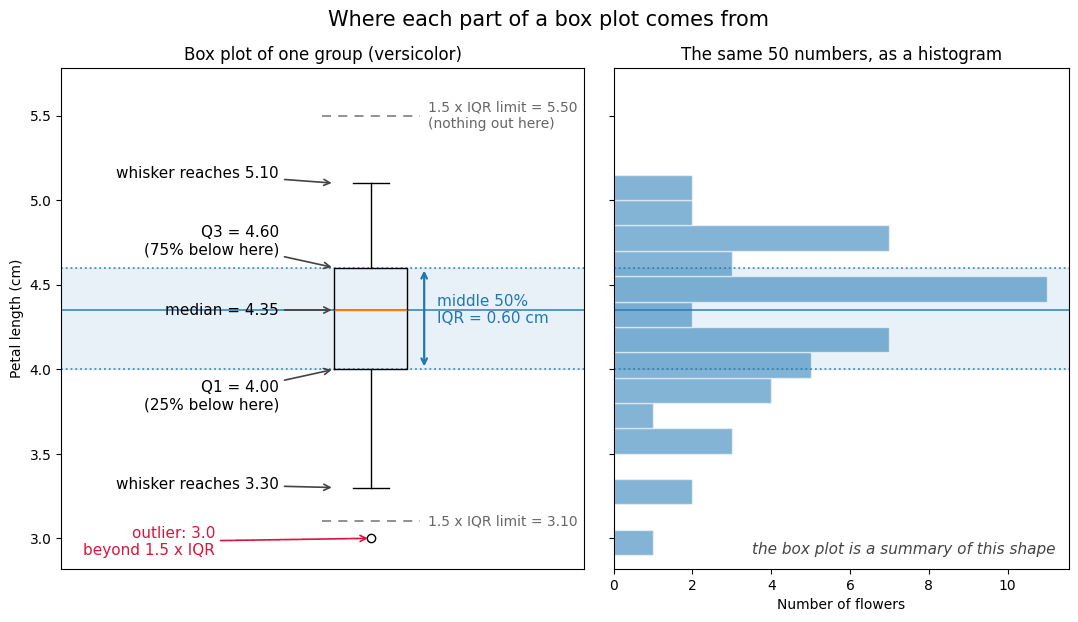

In [ ]:
fig, (ax_box, ax_hist) = plt.subplots(
    1, 2, figsize=(13, 6.5), sharey=True,
    gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.06})

# ---- shared horizontal guides, so the eye can carry each level across ----
for ax in (ax_box, ax_hist):
    ax.axhspan(q1, q3, color="tab:blue", alpha=0.10)
    for level, style in [(q1, ":"), (median, "-"), (q3, ":")]:
        ax.axhline(level, color="tab:blue", linestyle=style, linewidth=1.3, alpha=0.8)

# ---- left: the box plot itself ----
ax_box.boxplot(versicolor, positions=[1.45], widths=0.34, vert=True)
ax_box.set_xlim(0, 2.45)
ax_box.set_xticks([])
ax_box.set_ylim(2.82, 5.78)
ax_box.set_ylabel("Petal length (cm)")
ax_box.set_title("Box plot of one group (versicolor)")

def label(text, y, x_text, y_text=None):
    ax_box.annotate(text, xy=(1.28, y), xytext=(x_text, y_text if y_text else y),
                    fontsize=11, ha="right", va="center",
                    arrowprops={"arrowstyle": "->", "linewidth": 1.2, "color": "#444"})

label(f"median = {median:.2f}", median, 1.02)
label(f"Q3 = {q3:.2f}\n(75% below here)", q3, 1.02, q3 + 0.16)
label(f"Q1 = {q1:.2f}\n(25% below here)", q1, 1.02, q1 - 0.16)
label(f"whisker reaches {upper_whisker:.2f}", upper_whisker, 1.02, upper_whisker + 0.06)
label(f"whisker reaches {lower_whisker:.2f}", lower_whisker, 1.02, lower_whisker + 0.02)
ax_box.annotate(f"outlier: {outliers.iloc[0]:.1f}\nbeyond 1.5 x IQR", xy=(1.45, outliers.iloc[0]),
                xytext=(0.72, outliers.iloc[0] - 0.02), fontsize=11, ha="right", va="center",
                color="crimson",
                arrowprops={"arrowstyle": "->", "linewidth": 1.2, "color": "crimson"})

# the 1.5 x IQR limits: a calculation, not something a box plot normally shows
for fence in (lower_fence, upper_fence):
    ax_box.hlines(fence, 1.22, 1.68, color="#888", linestyle=(0, (5, 4)), linewidth=1.3)
ax_box.text(1.72, upper_fence, f"1.5 x IQR limit = {upper_fence:.2f}\n(nothing out here)",
            fontsize=10, va="center", color="#666")
ax_box.text(1.72, lower_fence, f"1.5 x IQR limit = {lower_fence:.2f}",
            fontsize=10, va="center", color="#666")

# the box itself spans the middle half of the data
ax_box.annotate("", xy=(1.70, q1), xytext=(1.70, q3),
                arrowprops={"arrowstyle": "<->", "linewidth": 1.6, "color": "tab:blue"})
ax_box.text(1.76, median, f"middle 50%\nIQR = {iqr:.2f} cm",
            fontsize=11, va="center", color="tab:blue")

# ---- right: the same numbers as a histogram, lying on its side ----
bins = np.arange(2.9, 5.35, 0.15)
ax_hist.hist(versicolor, bins=bins, orientation="horizontal",
             color="tab:blue", alpha=0.55, edgecolor="white")
ax_hist.set_xlabel("Number of flowers")
ax_hist.set_title("The same 50 numbers, as a histogram")
ax_hist.text(0.97, 0.03, "the box plot is a summary of this shape",
             transform=ax_hist.transAxes, ha="right", fontsize=11, style="italic", color="#444")

fig.suptitle("Where each part of a box plot comes from", fontsize=15, y=0.97)
plt.show()

Read the two panels together.

The shaded band is the **box**: it starts at Q1 and ends at Q3, so it holds about half the flowers —
28 of the 50 here. It is not exactly half, and cannot be: petal lengths are recorded to 0.1 cm, five
of these flowers sit exactly on Q1 and three exactly on Q3, and no cut can divide tied values.
The solid line across both panels is the **median**, with 25 flowers above and 25 below.

The **whiskers** reach out to the most extreme values that are still within 1.5 interquartile
ranges of the box. Everything beyond that is drawn as an individual point: here one flower with a
petal length of 3.0 cm, visible in the histogram as the isolated bar on the far left.

The 1.5 is a convention, not a law, and a point beyond it is a **candidate** for investigation
rather than an error. In this case 3.0 cm is a perfectly plausible petal.

### How far do the whiskers actually reach?

The rule has two steps, and the second is the one that catches people out.

**First**, compute a limit at one and a half interquartile ranges beyond each end of the box. These
limits are usually called **fences**:

$$
\text{lower fence} = Q_1 - 1.5 \times \text{IQR} = 4.00 - 0.90 = 3.10
$$
$$
\text{upper fence} = Q_3 + 1.5 \times \text{IQR} = 4.60 + 0.90 = 5.50
$$

**Second — and this is the part that surprises people — the whisker does not extend to the fence.**
It stops at the most extreme observation that still lies inside it.

Here the smallest petal at or above 3.10 cm measures **3.30**, and the largest at or below 5.50 cm
measures **5.10**. Those are where the whiskers end, 0.20 cm and 0.40 cm short of the fences. The
fences are drawn as grey dashes in the figure so that the gap is visible; a real box plot never
shows them.

Three consequences follow.

- **Whisker length is not fixed.** Two groups with the same box can have very different whiskers,
  because the whiskers are set by where the data happen to stop.
- **A whisker well short of its fence means the data simply run out there**, not that anything was
  excluded.
- **Anything beyond a fence is drawn individually** rather than being absorbed into a whisker.
  That is the single flower at 3.0 cm.

The whiskers therefore carry real information about the range of the data, while remaining immune
to a single extreme value dragging them out — which is exactly what the mean and standard
deviation fail to do, as the pitfalls in section 6 show.

The comparison also makes the box plot's main weakness visible.

The histogram shows the *shape* of the distribution. The box plot keeps only five numbers from it.
Those five are enough to compare many groups at a glance, which is exactly what section 3.3's plot
did for three species at once — but a distribution split into two separate humps would produce a
perfectly ordinary-looking box, and you would never know.

> Use a box plot to compare groups. Use a histogram to understand one.

## 3.4 Choosing between plot types

Different questions call for different plots.

| Question | Suitable plot |
|---|---|
| How is one variable distributed? | Histogram |
| How do two variables relate? | Scatter plot |
| How does one variable differ across groups? | Box plot, or overlaid histograms |
| Do groups separate in two variables? | Scatter plot coloured by group |
| Which variables relate to which? | Scatter matrix, correlation heatmap |

There is no single correct plot. The useful question is always:

> What do I want to find out, and which plot would make that visible?

<div class="alert alert-success">
<b>Mini-exercise 3 — Group comparison</b><br>
Using the Iris dataset:
<br><br>
1. Create a scatter plot of <code>petal_length</code> versus <code>petal_width</code>, with one colour per species.<br>
2. Create a box plot of <code>sepal_width</code> by species.<br>
3. Compare the petal scatter plot with the sepal scatter plot in Section 3.2.<br>
4. Which pair of measurements would you choose if you had to distinguish the three species? Why?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 4. Correlation

Plots are powerful, but we sometimes want a **number** that summarises how strongly two variables are related.

The most common such number is the **correlation coefficient**.

## 4.1 What correlation measures

For two variables $x$ and $y$ with $n$ observations, the Pearson correlation coefficient is

$$
r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
         {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}}
$$

The value always lies between -1 and +1:

- $r$ close to +1: a strong **positive linear** relationship;
- $r$ close to -1: a strong **negative linear** relationship;
- $r$ close to 0: little or no **linear** relationship.

The word *linear* is doing a great deal of work in those statements, and Section 4.4 shows why.

Note also that $r$ is dimensionless and unaffected by the units of measurement. Converting from centimetres to millimetres does not change the correlation.

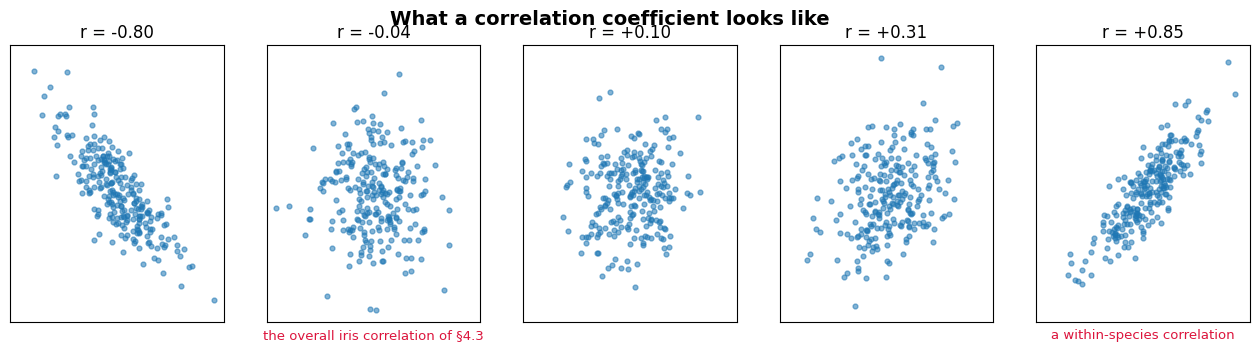

In [ ]:
shown = [-0.80, -0.12, 0.00, 0.40, 0.87]
draw = np.random.default_rng(3)

fig, axes = plt.subplots(1, len(shown), figsize=(16, 3.6), sharex=True, sharey=True)
for axis, target in zip(axes, shown):
    a = draw.normal(size=250)
    b = target * a + np.sqrt(max(1 - target ** 2, 0.0)) * draw.normal(size=250)
    axis.scatter(a, b, s=12, alpha=0.55)
    axis.set_title(f"r = {np.corrcoef(a, b)[0, 1]:+.2f}", fontsize=12)
    axis.set_xticks([]); axis.set_yticks([]); axis.grid(False)
axes[1].set_xlabel("the overall iris correlation of §4.3", fontsize=9.5, color="crimson")
axes[4].set_xlabel("a within-species correlation", fontsize=9.5, color="crimson")
fig.suptitle("What a correlation coefficient looks like", fontsize=14, fontweight="bold")
plt.show()

## 4.2 The correlation matrix

The method `.corr()` computes the correlation between every pair of numerical columns.

The result is a **correlation matrix**: symmetric, with ones on the diagonal, since every variable is perfectly correlated with itself.

Some later cells use `np.corrcoef(x, y)[0, 1]` instead. It is the same Pearson coefficient; NumPy
returns the whole two-by-two matrix for a pair of variables, so the `[0, 1]` picks out the single
off-diagonal number.

In [ ]:
iris[numeric_columns].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


Reading this table:

- `petal_length` and `petal_width` have correlation about 0.96, which is very strong;
- `sepal_length` correlates strongly with both petal measurements, about 0.87 and 0.82;
- `sepal_width` correlates weakly and *negatively* with everything else.

This matches what the scatter matrix showed in Section 2.4, but now with numbers attached.

The very high correlation between the two petal variables is worth noticing. It means they carry largely **redundant** information. Later in the course, when we study dimensionality reduction, this redundancy is exactly what we will exploit.

## 4.3 Visualizing the correlation matrix

For four variables the table is easy to read.

For fifty variables it is not. A **heatmap** makes the structure visible at a glance.

We use a diverging colour map centred on zero, so that positive and negative correlations are visually distinct.

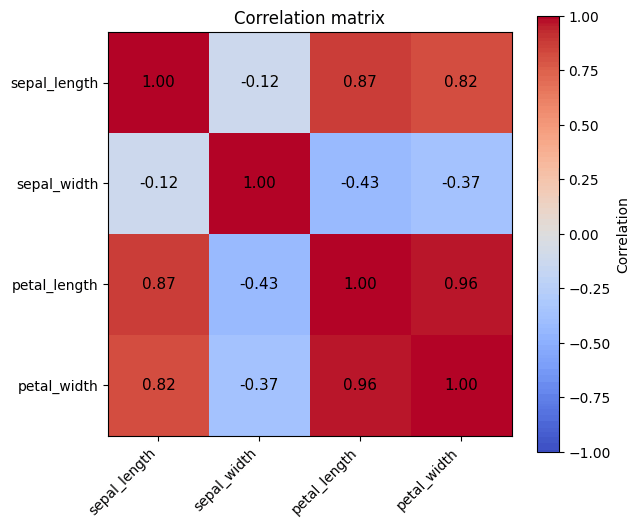

In [ ]:
corr = iris[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))
ax.set_xticklabels(numeric_columns, rotation=45, ha="right")
ax.set_yticklabels(numeric_columns)

# Write the numerical value inside each cell
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=11)

fig.colorbar(image, label="Correlation")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

The block of warm colours in the lower right corner immediately shows the group of mutually correlated variables.

The cool row and column for `sepal_width` show that it behaves differently from the rest.

For datasets with many variables, this kind of plot is often the fastest way to spot redundant measurements.

## 4.4 Correlation only captures linear relationships

A correlation near zero does **not** mean the variables are unrelated.

It means they are not *linearly* related.

The example below constructs a perfect parabolic relationship, where $y$ is completely determined by $x$.

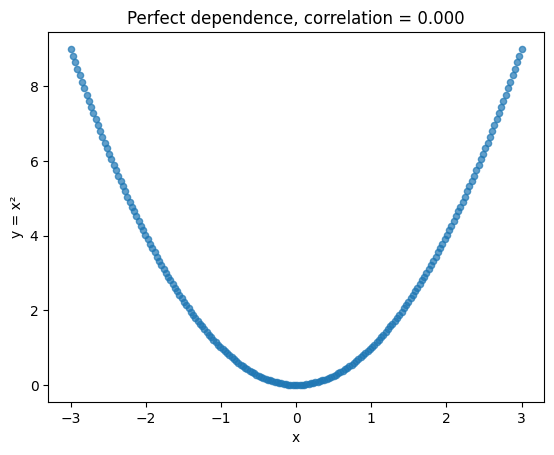

In [ ]:
# A symmetric grid, so the correlation is exactly zero rather than merely small.
x = np.linspace(-3, 3, 200)
y = x ** 2

plt.scatter(x, y, s=20, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y = x²")
# Zero by symmetry. Rounding away the floating-point dust (it comes out at about
# -1e-17) stops the title from reading "-0.000".
correlation = round(np.corrcoef(x, y)[0, 1], 6) + 0

plt.title(f"Perfect dependence, correlation = {correlation:.3f}")
plt.show()

The correlation is exactly zero, yet $y$ is a deterministic function of $x$: knowing $x$ tells you
$y$ precisely. The symmetry is what forces the coefficient to vanish — every rise on the right of
the parabola is matched by an equal fall on the left.

Contrast this with section 4.5, where a correlation of $-0.118$ turns out to be worth taking
seriously. Neither number can be judged by its size alone.

Any analysis that screened variables purely by correlation would discard $x$ as uninformative, even though it predicts $y$ perfectly.

This is a genuine hazard in scientific data analysis. The lesson is simple:

> Always plot the data. Never rely on a correlation coefficient alone.

### Rank correlation: when the relationship bends but never turns back

Between a straight line and a parabola lies a very common case: a relationship that always goes the
same way — $y$ rises whenever $x$ rises — but not along a straight line. Exponential growth, a
response that saturates, a detector that flattens out at high intensity. Pearson's $r$ undersells
these, because what it measures is how close the points lie to a *straight* line.

**Spearman's rank correlation**, written $\rho$ (rho), asks a weaker and often more useful question:
does $y$ tend to go up when $x$ goes up, however the curve bends? The recipe is short. Replace every
value by its **rank** within its own variable — 1 for the smallest, 2 for the next, and so on — and
compute Pearson's $r$ on the ranks. A relationship that only ever rises gives both variables the
same ranks, so $\rho = 1$ exactly, however curved it is. In pandas it is one argument:
`.corr(method="spearman")`.

The cell below compares the two coefficients on two small datasets.

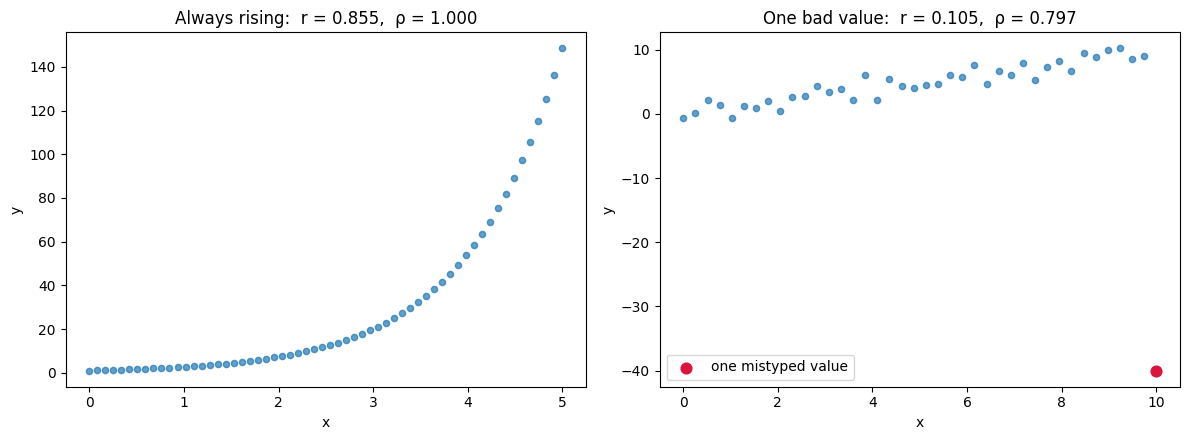

the noisy line, before the typo:  r = 0.940,  rho = 0.942
the parabola of the cell above:   r = +0.000,  rho = -0.004

the iris measurements, by Spearman rather than Pearson:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.167,0.882,0.834
sepal_width,-0.167,1.000,-0.310,-0.289
petal_length,0.882,-0.310,1.000,0.938
petal_width,0.834,-0.289,0.938,1.000


In [ ]:
# Two small datasets on which Pearson's r and Spearman's rho tell different stories.
curve_x = np.linspace(0, 5, 60)
curve_y = np.exp(curve_x)                          # always rising, far from straight

line_rng = np.random.default_rng(4)
line_x = np.linspace(0, 10, 40)
line_y = line_x + line_rng.normal(0, 1.0, 40)      # a noisy straight line ...
typo_y = line_y.copy()
typo_y[-1] = -40                                   # ... and the same with one mistyped value


def both(a, b):
    """Pearson's r and Spearman's rho for two sequences of numbers."""
    a, b = pd.Series(a), pd.Series(b)
    return a.corr(b), a.corr(b, method="spearman")


fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5))

r, rho = both(curve_x, curve_y)
left.scatter(curve_x, curve_y, s=20, alpha=0.7)
left.set_title(f"Always rising:  r = {r:.3f},  ρ = {rho:.3f}")

r_clean, rho_clean = both(line_x, line_y)
r, rho = both(line_x, typo_y)
right.scatter(line_x[:-1], typo_y[:-1], s=20, alpha=0.7)
right.scatter(line_x[-1], typo_y[-1], s=60, color="crimson", label="one mistyped value")
right.set_title(f"One bad value:  r = {r:.3f},  ρ = {rho:.3f}")
right.legend(loc="lower left")

for axis in (left, right):
    axis.set_xlabel("x")
    axis.set_ylabel("y")
plt.tight_layout()
plt.show()

print(f"the noisy line, before the typo:  r = {r_clean:.3f},  rho = {rho_clean:.3f}")
print(f"the parabola of the cell above:   r = {round(both(x, y)[0], 6) + 0:+.3f},  "
      f"rho = {both(x, y)[1]:+.3f}")
print("\nthe iris measurements, by Spearman rather than Pearson:")
iris[numeric_columns].corr(method="spearman").round(3)

Read the two panels and the lines under them.

- **Left.** Every step up in $x$ is a step up in $y$, so $\rho = 1.000$. Pearson's $0.855$ calls the
  same data "strong but imperfect", only because the curve is not straight.
- **Right.** One mistyped value — the red point — drags Pearson's $r$ from 0.940 down to 0.105.
  Spearman's $\rho$ goes from 0.942 to 0.797: to a ranking, a wild value is simply the smallest one,
  however wild it is. That robustness is the second reason $\rho$ is worth knowing.
- **The parabola** of the cell above gets $\rho \approx 0$ as well. Rank correlation widens
  "related" from straight lines to any curve that keeps going the same way, and no further: a $y$
  that falls and then rises still defeats it. The rule above stands — plot first.

On the iris measurements the two tables tell the same story: the numbers shift a little, but every
pair keeps its sign and its place in the order from strongest to weakest. That is the usual outcome
for well-behaved measurements. When the two tables disagree sharply, it is a signal to go back to
the scatter plot and find out why.

## 4.5 Simpson's paradox: grouping can reverse a correlation

Here is a more subtle effect, and one that appears in the Iris data itself.

Let us compute the correlation between sepal length and sepal width for the whole dataset, and then separately within each species.

In [ ]:
overall = iris["sepal_length"].corr(iris["sepal_width"])
print(f"Overall correlation:  {overall:.3f}")

print("\nWithin each species:")
for species, group in iris.groupby("species"):
    r = group["sepal_length"].corr(group["sepal_width"])
    print(f"  {species:12s} {r:+.3f}")

Overall correlation:  -0.118

Within each species:
  setosa       +0.743
  versicolor   +0.526
  virginica    +0.457


The overall correlation is slightly **negative**, about -0.12.

Within every single species it is clearly **positive**, between about +0.46 and +0.74.

So the relationship reverses sign depending on whether we account for species.

This phenomenon is known as **Simpson's paradox**. It happens because the three species have different average sepal lengths and widths, and mixing them together creates a spurious overall trend that contradicts the trend inside each group.

The plot below makes it visible. To draw the trend inside each group we use `np.polyfit`, met in `01A` §8.2. We meet the fit itself
properly in the next class; here it is only a drawing tool.

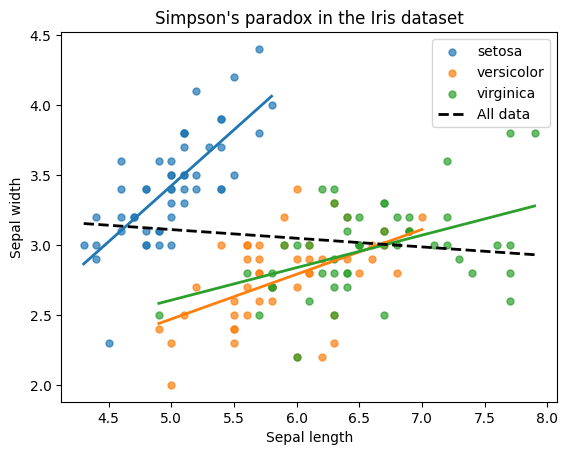

In [ ]:
for species, group in iris.groupby("species"):
    plt.scatter(group["sepal_length"], group["sepal_width"], label=species, s=25, alpha=0.7)

    # Fit and draw a straight line within this species
    slope, intercept = np.polyfit(group["sepal_length"], group["sepal_width"], 1)
    xs = np.linspace(group["sepal_length"].min(), group["sepal_length"].max(), 10)
    plt.plot(xs, slope * xs + intercept, linewidth=2)

# Straight line fitted to all the data together
slope, intercept = np.polyfit(iris["sepal_length"], iris["sepal_width"], 1)
xs = np.linspace(iris["sepal_length"].min(), iris["sepal_length"].max(), 10)
plt.plot(xs, slope * xs + intercept, "k--", linewidth=2, label="All data")

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Simpson's paradox in the Iris dataset")
plt.legend()
plt.show()

The three coloured lines all slope upwards. The black dashed line, fitted to everything at once, slopes downwards.

The practical consequence for scientific work is serious. If a dataset contains distinct sub-populations, an aggregate statistic can point in the opposite direction from the truth within every sub-population.

Whenever a dataset contains groups, ask whether the analysis should be done within groups.

## 4.6 Correlation is not causation

Two variables can be strongly correlated for several distinct reasons:

- $x$ influences $y$;
- $y$ influences $x$;
- a third variable influences both (a **confounder**);
- the sample was selected in a way that induces a relationship;
- coincidence, especially with few observations or many variables tested.

In the Iris data, petal length and petal width are strongly correlated, but neither causes the other. Both are consequences of the flower's species and size.

Correlation restricts the set of plausible explanations. It does not select among them.

<div class="alert alert-success">
<b>Mini-exercise 4 — Correlation</b><br>
Using the Iris dataset:
<br><br>
1. Compute the correlation matrix separately for each species, using <code>groupby</code>.<br>
2. Compare these with the overall correlation matrix from Section 4.2.<br>
3. Are there other pairs of variables, besides sepal length and width, whose correlation changes noticeably when species is taken into account?<br>
4. Explain in one or two sentences why this happens.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. Mini case study: can species be distinguished?

We now put the tools of this notebook together.

Without fitting any machine learning model, we can already ask a question that sounds like a modelling question:

> Do the measurements contain enough structure to distinguish the three species?

If the answer is clearly yes, a classifier will probably work well. If the answer is no, no amount of modelling will rescue us, and we need better measurements instead.

This is the value of exploratory analysis: it tells us what to expect before we spend effort on models.

## 5.1 Group-wise averages

We start with the simplest possible summary: the mean of each measurement within each species.

In [ ]:
iris.groupby("species")[numeric_columns].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


The petal measurements differ dramatically between species. Petal length rises from roughly 1.5 to 4.3 to 5.6.

The sepal measurements differ much less, and `sepal_width` barely differs at all.

This is a first indication that the petal measurements carry most of the useful information.

## 5.2 Visual separation

Means alone can be misleading, because two groups with different means may still overlap heavily if their spread is large.

So we look at the actual points.

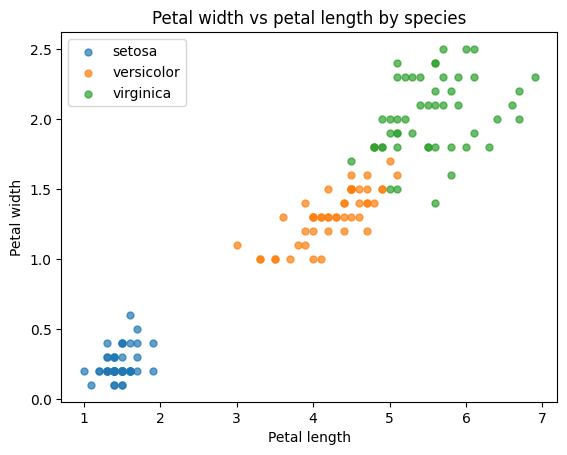

In [ ]:
for species, group in iris.groupby("species"):
    plt.scatter(group["petal_length"], group["petal_width"], label=species, s=25, alpha=0.7)

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Petal width vs petal length by species")
plt.legend()
plt.show()

This is a much clearer picture than any of the sepal plots.

`setosa` is completely separated from the others, with a wide empty gap.

`versicolor` and `virginica` form distinct groups that touch at their boundary but overlap only slightly.

A simple rule of the form "if petal length is below 2.5, predict setosa" would already classify one species perfectly.

## 5.3 Quantifying separation

"Clearly separated" is a visual impression. Can we attach a number to it?

A simple approach is to compare two quantities for each measurement:

- how much the **group means** differ from one another (the between-group spread);
- how much the values **vary within** each group (the within-group spread).

A measurement is useful for distinguishing groups when the first is large compared to the second.

In [ ]:
print(f"{'variable':16s} {'between':>9s} {'within':>9s} {'ratio':>8s}")
print("-" * 45)

for column in numeric_columns:
    group_means = iris.groupby("species")[column].mean()
    group_stds = iris.groupby("species")[column].std()

    between = group_means.std()      # spread of the group means
    within = group_stds.mean()       # typical spread inside a group

    print(f"{column:16s} {between:9.2f} {within:9.2f} {between / within:8.2f}")

variable           between    within    ratio
---------------------------------------------
sepal_length          0.80      0.50     1.59
sepal_width           0.34      0.34     1.00
petal_length          2.09      0.40     5.25
petal_width           0.90      0.19     4.66


The ratios rank the measurements clearly:

- `petal_length` — about 5.2
- `petal_width` — about 4.7
- `sepal_length` — about 1.6
- `sepal_width` — about 1.0

The petal measurements are three to five times more discriminative than the sepal measurements.

This confirms the visual impression numerically, and it is a simplified version of an idea we will meet again: assessing how informative a feature is before, or instead of, using it in a model.

## 5.4 What we learned without fitting a model

Using only loading, summarising and plotting, we have established that:

- the dataset has 150 rows, 4 numerical measurements and 1 categorical label;
- there are no missing values;
- the three species are balanced, 50 samples each;
- petal measurements separate the species well; sepal measurements do not;
- `setosa` is perfectly separable; `versicolor` and `virginica` overlap slightly;
- petal length and petal width are highly redundant with each other.

Every one of these findings would shape how we approach a model.

The last point in particular predicts something specific: since a single well-chosen measurement nearly determines the species, a very simple classifier should perform almost as well as a complicated one.

This naturally motivates the next part of the course:

> Can we build a model that automatically predicts the species from the measurements, and how would we know whether it is any good?

# 6. Common pitfalls

The nine mistakes below are common, and all of them have appeared in published scientific work.
They cover both halves of this class: the first three concern the handling steps of `01C`, and the
rest the plots and correlations of this notebook.

Three of them can be shown rather than described, so those three carry a figure. That is a
difference in how easily each one is demonstrated, not in how much it matters.

## 6.1 Assuming the data loaded correctly

A file may load without raising an error and still be wrong: the wrong separator, a header row
treated as data, numbers read as text, or silently truncated rows. Always inspect shape, types and
a few rows after loading.

## 6.2 Ignoring missing values

Missing entries are rarely missing at random. Instruments fail under particular conditions, and
measurements below a detection threshold are often recorded as blank. Dropping them silently can
bias a whole analysis.

## 6.3 Confusing rows and columns

Rows are observations; columns are variables. Transposing the two produces results that look
plausible and are meaningless.

## 6.4 Trusting summary statistics alone

A mean tells us nothing about shape, spread, groups or outliers.

The classic demonstration is **Anscombe's quartet**: four datasets constructed so that their
summary statistics agree to two decimal places. Same mean in each variable, same standard
deviation, same correlation, and the same fitted straight line.

In [ ]:
anscombe_x = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], dtype=float)
anscombe_x4 = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], dtype=float)

quartet = {
    "I":   (anscombe_x,  np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "II":  (anscombe_x,  np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    "III": (anscombe_x,  np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    "IV":  (anscombe_x4, np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}

print(f"{'set':5}{'mean x':>9}{'mean y':>9}{'sd x':>8}{'sd y':>8}{'corr':>8}")
for name, (x_values, y_values) in quartet.items():
    print(f"{name:5}{x_values.mean():>9.2f}{y_values.mean():>9.2f}"
          f"{x_values.std(ddof=1):>8.2f}{y_values.std(ddof=1):>8.2f}"
          f"{np.corrcoef(x_values, y_values)[0, 1]:>8.3f}")

set     mean x   mean y    sd x    sd y    corr
I         9.00     7.50    3.32    2.03   0.816
II        9.00     7.50    3.32    2.03   0.816
III       9.00     7.50    3.32    2.03   0.816
IV        9.00     7.50    3.32    2.03   0.817


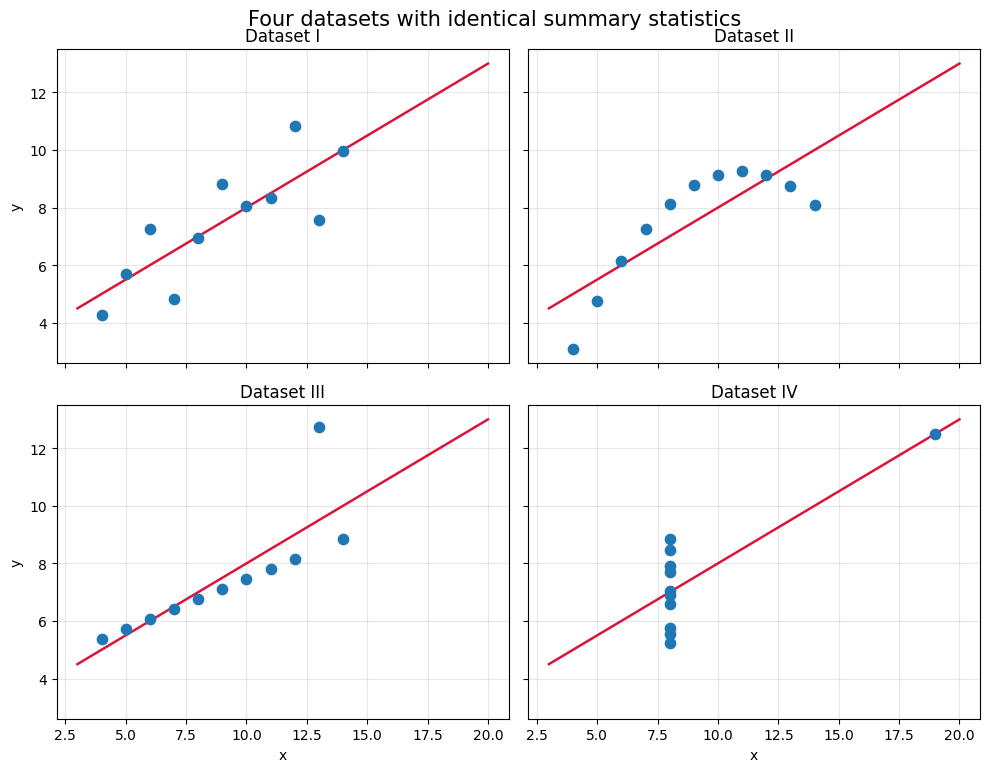

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, (name, (x_values, y_values)) in zip(axes.ravel(), quartet.items()):
    ax.scatter(x_values, y_values, s=55, zorder=3)

    # Every one of the four is fitted by exactly the same straight line.
    line_x = np.linspace(3, 20, 10)
    ax.plot(line_x, 3.0 + 0.5 * line_x, color="crimson", linewidth=1.8, zorder=2)

    ax.set_title(f"Dataset {name}", fontsize=12)
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")

fig.suptitle("Four datasets with identical summary statistics", fontsize=15, y=0.96)
plt.tight_layout()
plt.show()

The four are nothing alike.

**I** is a genuine noisy linear relationship, and the fitted line is a fair summary of it.
**II** is a clean curve, and a straight line is simply the wrong shape.
**III** is perfectly linear apart from one aberrant point, which drags the line away from every
other observation.
**IV** contains no relationship at all: ten observations at the same $x$, and one distant point that
invents a slope single-handedly.

Any analysis that reported only "mean 9.00 and 7.50, correlation 0.82, slope 0.50" would describe
all four identically, and would be badly misleading about three of them.

> Plot the data. Summary statistics are a compression, and compression loses things.

## 6.5 Interpreting correlation as causation

A correlation constrains the set of explanations; it does not choose among them. Section 4.4 also
showed the converse trap: near-zero correlation does not mean the variables are unrelated.

## 6.6 Ignoring group structure

As section 4.5 showed, an aggregate trend can reverse within every subgroup.

## 6.7 Plotting without labels

An unlabelled plot is not interpretable by a reader, and after two weeks it is not interpretable
by its author either.

Both panels below show exactly the same data.

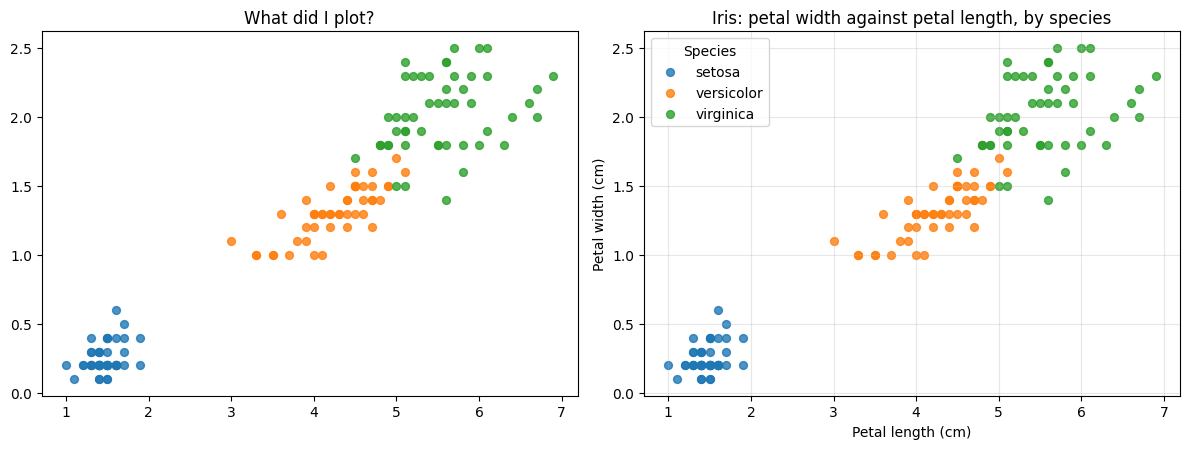

In [ ]:
fig, (bare, labelled) = plt.subplots(1, 2, figsize=(12, 4.6))

for ax in (bare, labelled):
    for species, group in iris.groupby("species"):
        ax.scatter(group["petal_length"], group["petal_width"], s=32, alpha=0.8, label=species)

bare.set_title("What did I plot?")

labelled.set_xlabel("Petal length (cm)")
labelled.set_ylabel("Petal width (cm)")
labelled.set_title("Iris: petal width against petal length, by species")
labelled.legend(title="Species")
labelled.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The left panel is not wrong. It is simply useless to anyone who was not in the room when it was
made — including you, later. Axis labels, units, and a legend cost seconds.

## 6.8 Choosing a plot that obscures the structure

Overplotted scatter plots and misleading axis ranges were covered in section 2. The most common
offender in published work, though, is the bar chart of group means.

The three groups below have been constructed to have **exactly the same mean**.

In [ ]:
rng = np.random.default_rng(7)

group_a = rng.normal(10.0, 0.4, 40)                                    # one tight cluster
group_b = np.concatenate([rng.normal(8.2, 0.35, 20),
                          rng.normal(11.8, 0.35, 20)])                 # two separate humps
group_c = np.concatenate([rng.normal(9.3, 0.3, 37),
                          rng.normal(19.0, 0.4, 3)])                   # a cluster plus extremes

# Shift each to exactly the same mean, so the bars are provably identical.
groups = {name: values - values.mean() + 10.0
          for name, values in [("A", group_a), ("B", group_b), ("C", group_c)]}

for name, values in groups.items():
    print(f"group {name}:  mean = {values.mean():.2f}   std = {values.std(ddof=1):.2f}")

group A:  mean = 10.00   std = 0.33
group B:  mean = 10.00   std = 1.81
group C:  mean = 10.00   std = 2.62


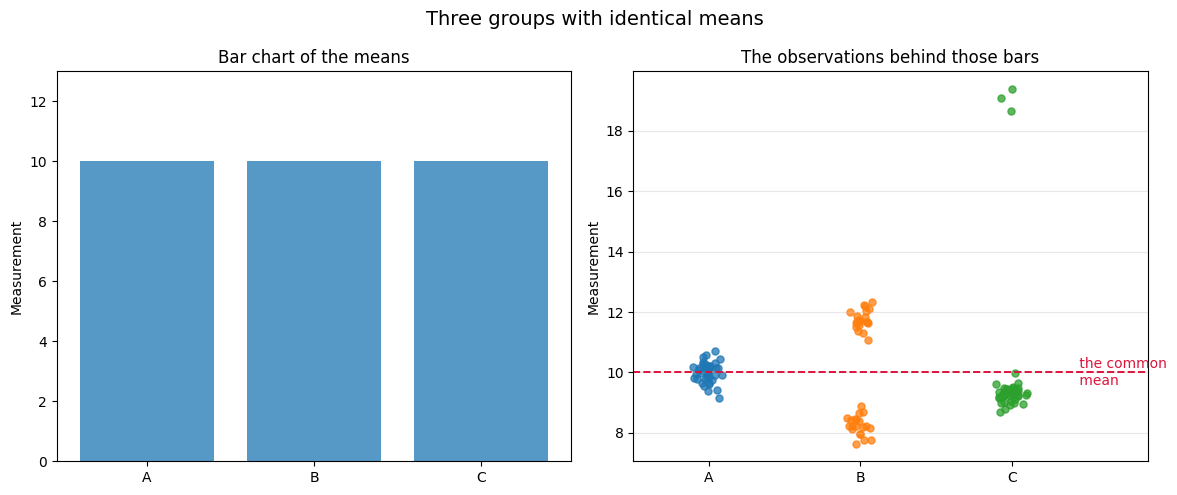

In [ ]:
fig, (bars, points) = plt.subplots(1, 2, figsize=(12, 5))

bars.bar(list(groups), [v.mean() for v in groups.values()], color="tab:blue", alpha=0.75)
bars.set_ylabel("Measurement")
bars.set_title("Bar chart of the means")
bars.set_ylim(0, 13)

for offset, (name, values) in enumerate(groups.items()):
    jitter = rng.normal(0, 0.05, len(values))
    points.scatter(np.full(len(values), offset) + jitter, values, s=26, alpha=0.75)

points.axhline(10.0, color="crimson", linewidth=1.4, linestyle="--")
points.text(2.42, 10.0, " the common\n mean", color="crimson", fontsize=10, va="center")

points.set_xticks(range(len(groups)))
points.set_xticklabels(list(groups))
points.set_ylabel("Measurement")
points.set_title("The observations behind those bars")
points.grid(alpha=0.3, axis="y")
points.set_xlim(-0.5, 2.9)

fig.suptitle("Three groups with identical means", fontsize=14)
plt.tight_layout()
plt.show()

The bar chart shows three identical rectangles, and would support the conclusion that the groups
are indistinguishable.

They are nothing of the sort. **A** is a single tight cluster. **B** is two separated populations
with almost nobody at the mean itself — the bar marks a value that barely occurs. **C** is a tight
cluster plus three extreme observations that carry the average upwards on their own.

A bar chart of means shows one number per group and hides everything else. Show the observations,
or at least a box plot, whenever there is room.

## 6.9 Modelling before understanding the data

This is the most expensive mistake, because it can waste weeks. Time spent on exploratory analysis
is almost always recovered.

# 7. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — First exploratory report</b><br>
Write a short exploratory report on the Iris dataset.
<br><br>
Your report should include:
<br><br>
1. number of rows and columns;<br>
2. column names and data types;<br>
3. number of samples per species;<br>
4. mean values grouped by species;<br>
5. one histogram;<br>
6. one scatter plot;<br>
7. two or three sentences describing what you observe.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Relationship between variables</b><br>
Investigate the relationship between petal length and petal width.
<br><br>
1. Make a scatter plot.<br>
2. Compute the correlation between the two variables.<br>
3. Compute the correlation again separately within each species.<br>
4. Comment on whether the relationship appears weak, moderate or strong, and on whether it changes when species is taken into account.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — A new dataset</b><br>
Apply the whole workflow of <code>01C</code> and <code>01D</code> to a dataset you have not seen before.
<br><br>
Load the penguins dataset:
<br><br>
<code>url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"</code>
<br><br>
Then:
<br><br>
1. Inspect its shape, columns and data types.<br>
2. Check for missing values and decide how to handle them, explaining your choice.<br>
3. Identify which columns are numerical and which are categorical.<br>
4. Produce at least one histogram, one scatter plot coloured by species, and a correlation matrix.<br>
5. Using the ratio idea from Section 5.3, decide which measurements best distinguish the species.<br>
6. Write three sentences summarising what you would tell a collaborator about this dataset.
<br><br>
This dataset is messier than Iris. That is the point.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- Histograms show distributions; scatter plots show relationships; box plots compare groups.
- A box plot is a five-number summary drawn to scale: median, quartiles, and whiskers that reach
  the furthest points still within 1.5 interquartile ranges of the box.
- Colour and grouping reveal structure that a single cloud of points hides.
- Correlation summarises *linear* relationship only. It can be zero for variables that determine
  each other exactly.
- Spearman's rank correlation is Pearson's computed on ranks. It is 1 for any relationship that
  only ever rises, however curved, and one wild value barely moves it — but it is still blind to a
  relationship that falls and then rises.
- A correlation computed over pooled groups can have the opposite sign to the correlation within
  every one of them.
- Summary statistics are a compression, and compression loses things. Plot the data.

# Optional preparation for the next class

Before the next class, students should be comfortable with:

- loading a CSV file and checking that it loaded correctly;
- inspecting a pandas DataFrame with `head`, `shape`, `info` and `describe`;
- checking for missing values;
- selecting columns, and filtering rows with a condition;
- deriving a new column;
- grouping data and computing group-wise summaries;
- making histograms, scatter plots and box plots;
- interpreting a correlation, and knowing what it cannot tell you.

In the next class we move from *describing* data to *predicting* from it, beginning with
regression.